# Example of usage of open_save code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 1.
r = 0.75

NGSOLVE = True

lc = 0.2

if NGSOLVE:
    from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
    #mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
    mesh = CleanCircle(R=R, verbosity=0, lc=lc)
else:
    raise NotImplementedError
    from cases.open_space.gmsh_geometries import CleanWaveguide, WaveguideRegions
    mesh = CleanWaveguide(R=R, H=H, verbose=True, lc=lc)


In [2]:
mesh.n_triangles

166

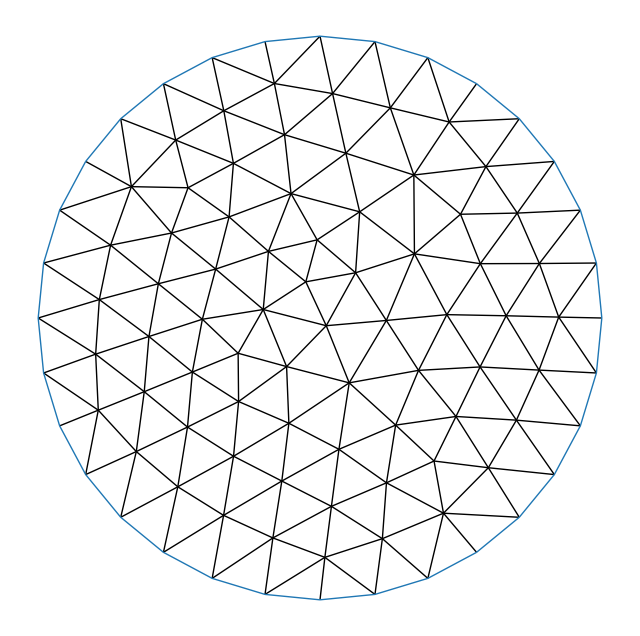

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [5]:
mesh.curve_region(Regions.SIGMA, radius=R)
#mesh.curve_region(Regions.d_Omega, radius=r)


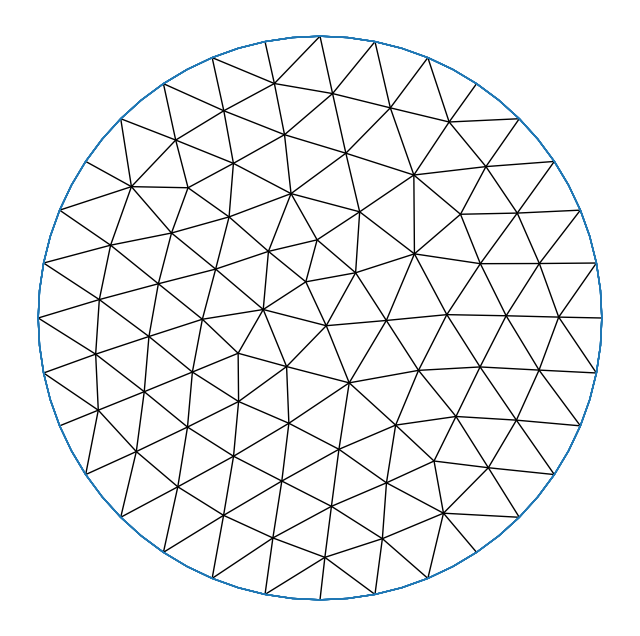

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
# boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, CircularDirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
from cases.open_space.kernels import NtDLocal_circle, NtDNonLocal_circle

Now the numerics (the configuration of kernels) is almost a dictionary:

In [88]:
from trefftz.dg.assemblers import SerialNumerics
NtD_modes = 5
# numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
#                           local_boundary_kernels={NtDBC: NtDLocal_circle(R=R, d_2=0.5, n=1), DirichletBC: CircularDirichletKernel(a=0.5, data=data)},
#                           nonlocal_boundary_kernels= {NtDBC: NtDNonLocal_circle(R=R, d_2=0.5, n=1, NtD_modes=NtD_modes)})
a = 0.5
b = 0.5
d1 = 0.5
d2 = 0.5
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: CircularDirichletFlux(a=a, data=data)},
                          nonlocal_boundary_kernels={})

We should also choose a local basis

In [117]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 5
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [118]:
basis.N_DOF

830

In [119]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [120]:
assembler._regions_RHS_term

[<Regions.SIGMA: 'Sigma'>]

so we can set the problem:

In [ ]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [122]:
A = P.assemble_LHS()

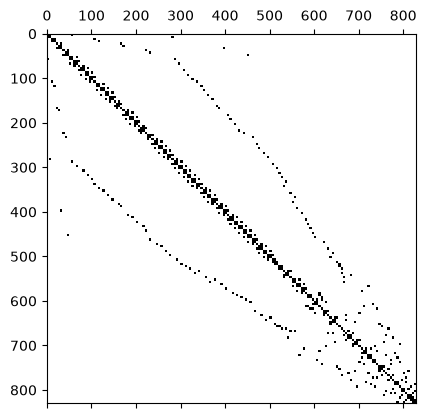

In [123]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [124]:
b = P.assemble_RHS()

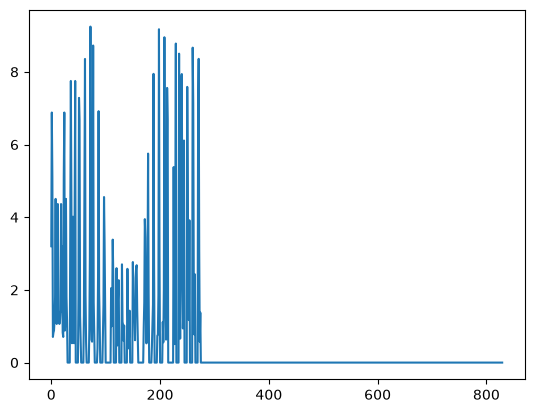

In [125]:
import numpy as np 
plt.plot(np.abs(b))

In [126]:
P.solve()

In [127]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-2.42439933e+01+1.16003687e+01j,  2.92824835e+01+4.47160968e+00j,
        -7.95232097e-01+2.10344341e+00j,  2.74147622e+00-5.17874949e+00j,
        -1.89374083e+00+9.78944294e-01j],
       [-5.82091564e+00+8.00951185e+00j,  1.18322844e+01-2.65845568e+01j,
        -1.23333866e+00-7.56163560e+01j,  5.48811986e-01+5.86352296e+00j,
        -7.24608242e+00+5.66215243e-01j],
       [-1.75900594e+00-3.88194494e-01j, -9.17687967e-01-1.68371575e+00j,
        -1.08055980e+01+1.22408242e+00j,  1.17547991e+01-1.79008490e+01j,
        -1.10628468e-01-8.10815240e-01j],
       [ 1.49786941e+00-2.03203714e+00j, -7.74033944e+00+4.57937416e+00j,
        -5.81124028e+00+1.09696352e+01j,  4.81980772e+00-1.52720207e+00j,
         1.25130856e+00-6.95070363e-02j],
       [-4.10108105e-01-1.68711153e+01j,  3.60157568e+00-1.85717405e+00j,
        -4.45193041e+00+3.60660409e+00j,  1.28054284e+00-2.01067344e+00j,
        -1.79140543e+01+9.67719606e+00j],
       [-3.91060240e-01-4.27525861e+00j,  1.935592

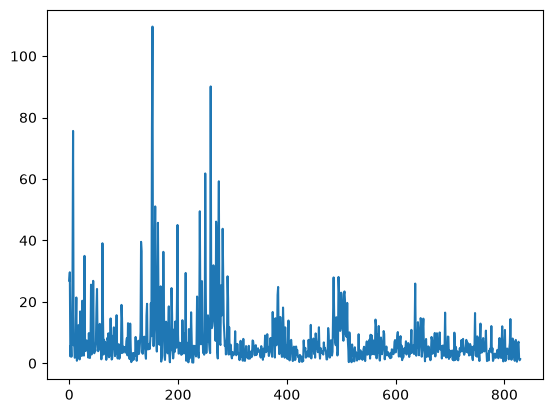

In [128]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [129]:
import numpy as np
N = 200
rs = np.linspace(r, R, N)
rs = np.linspace(0, R, N)

theta = np.linspace(0, 2*np.pi, N)
Rs, Theta = np.meshgrid(rs, theta)
X = Rs*np.cos(Theta)
Y = Rs*np.sin(Theta)
x = X.ravel()
y = Y.ravel() 
z = P.u_h(x, y)

(np.float64(-1.09986915899354),
 np.float64(1.100062304173604),
 np.float64(-1.099965731583572),
 np.float64(1.099965731583572))

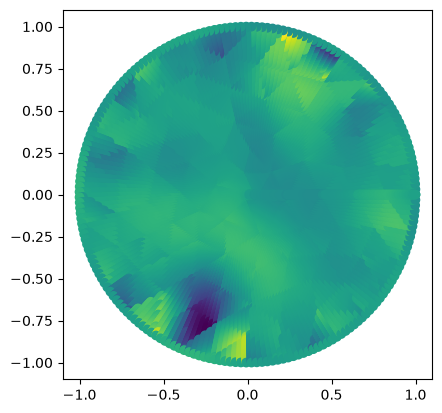

In [130]:
import matplotlib.pyplot as plt
plt.scatter(x,y,c=np.real(z),cmap="viridis")
plt.axis("square")